# Condori Romero Said - ING SISTEMAS

Punto 2.

Buscar un dataset de imágenes o audio que no tenga etiquetas, que tenga un n mayor a 10 y un m mayor a 10.000 ejemplos, en cualquier ámbito.
Los datasets no deben ser similares para ello deben coordinar esto con el universitario Helen Janko Sanga.
Aplicar aprendizaje semisupervisado
Aplicar aprendizaje activo

Detalle del Dataset: Devanagari Handwritten Character DatasetOrigen y Propósito: Este conjunto de datos fue recolectado y documentado por investigadores en Nepal (con documentación en IEEE Institute of Electrical and Electronics Engineers) para evaluar sistemas de Reconocimiento Óptico de Caracteres.

¿Qué contiene? Contiene imágenes de letras escritas a mano del alfabeto Devanagari (hindi (con más de 520 millones de hablantes), maratí (con más de 83 millones de hablantes) y nepalí (con más de 14 millones de hablantes)).

Volumen de datos: Posee 46 clases diferentes (diferentes letras/caracteres).

Formato técnico: Las imágenes están en formato .png con una resolución de $32 \times 32$ píxeles.

In [82]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [83]:

import numpy as np
import os
import cv2
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [84]:
ruta_test = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/DevanagariHandwrittenCharacterDataset/Test'

def load_unlabeled_data(base_path):
    X = []
    y_oculto = [] # Oráculo: solo para verificar al final, no para entrenar

    # Listar y ordenar las carpetas de clases
    clases = sorted(os.listdir(base_path))

    for class_idx, class_name in enumerate(clases):
        class_path = os.path.join(base_path, class_name)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                # Leemos la imagen en escala de grises
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    # Aplanamos la matriz de 32x32 a un vector de 1024 (espacio de características)
                    X.append(img.flatten())
                    y_oculto.append(class_idx)

    # Convertir listas a arreglos de numpy para procesamiento matemático
    return np.array(X), np.array(y_oculto)

# --- CORRECCIÓN DEL ORDEN ---
print("Iniciando la carga de la matriz de imágenes...")

# Primero llamamos a la función y asignamos los valores a X y y_oculto
X, y_oculto = load_unlabeled_data(ruta_test)

# Ahora que X existe, podemos imprimir su información
print(f"Carga finalizada.")
print(f"Forma de la matriz X: {X.shape}") # Debería ser (n_muestras, 1024)
print(f"Total de imágenes cargadas: {len(X)}")

Iniciando la carga de la matriz de imágenes...
Carga finalizada.
Forma de la matriz X: (13800, 1024)
Total de imágenes cargadas: 13800


##División de los datos (Train / Test)

In [85]:
from sklearn.model_selection import train_test_split
import numpy as np

# Aseguramos que las etiquetas sean de tipo entero
y_full = y_oculto.astype(np.int64)

# Dividimos el dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_full, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11040, 1024)
y_train shape: (11040,)
X_test shape: (2760, 1024)
y_test shape: (2760,)


# Aprendizaje Semi-Supervisado

## Agrupamos las imágenes para encontrar los representantes.

 aplicamos K-Means. Basándonos en la estructura lingüística del Devanagari (36 consonantes + 11 vocales + 10 dígitos)

In [375]:
from sklearn.cluster import KMeans

k = 57
kmeans = KMeans(n_clusters=k, random_state=42)

# calcula las distancias a los centroides
X_digits_dist = kmeans.fit_transform(X_train)

print(X_digits_dist.shape)

# Buscamos las imágenes más cercanas a cada centroide
idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

print(X_representative_digits.shape)

(11040, 57)
(57, 1024)


##Visualización
imagenes representativas


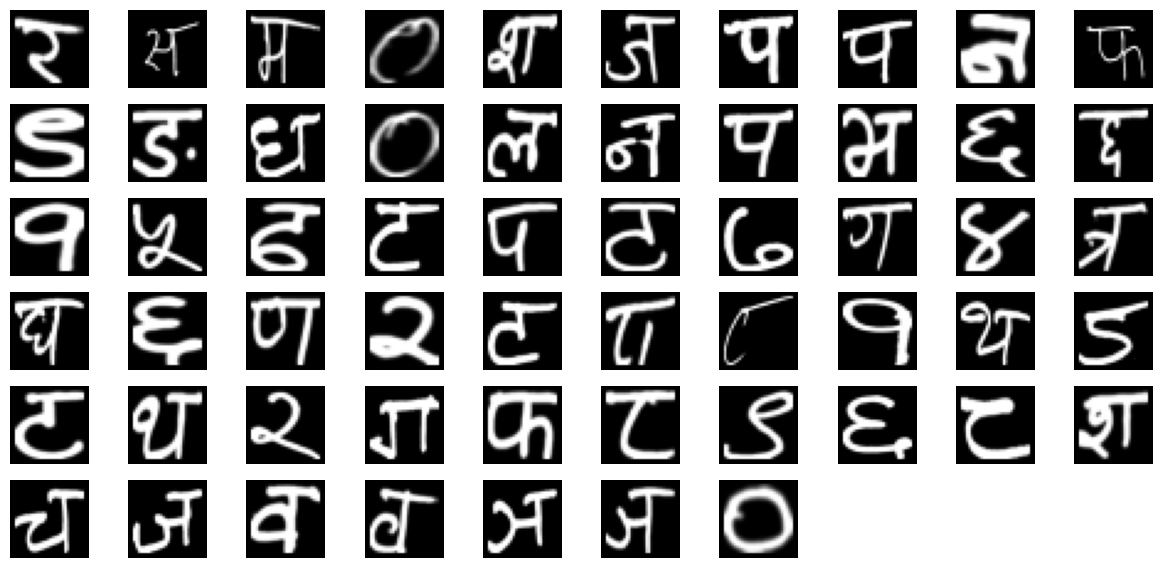

In [376]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(10, 10, index + 1)
    # Reconstruimos la imagen a 32x32 (1024 píxeles)
    plt.imshow(X_representative_digit.reshape(32, 32), cmap='gray')
    plt.axis('off')
plt.show()

Etiquetado
Simulamos que anotamos estas con la misma k imágenes y entrenamos un modelo.

In [377]:
y_representative_digits = y_train[idxs]

El primero utilizará las 57 imágenes representativas descubiertas por K-Means.

El segundo actuará como grupo de control, utilizando 57 imágenes elegidas totalmente al azar.


## 1ER

In [378]:
from sklearn.linear_model import LogisticRegression
# Entrenamos el modelo SOLO con las k imágenes representativas
log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_digits, y_representative_digits)
print(f"Precisión con las {k} imágenes representativas", log_reg2.score(X_test, y_test))


CPU times: user 774 ms, sys: 3.81 ms, total: 778 ms
Wall time: 537 ms
Precisión con las 57 imágenes representativas 0.27717391304347827


### Con 33 consonantes y los 10 digitos
K=43 -> 0.22391304347826088

K=44 -> 0.23079710144927537

K=45 -> 0.2289855072463768

### Con máximo de consonantes básicas en la escritura devanagari es de 36 y los 10 digitos

K=46 -> 0.24347826086956523

### Con 33 consonantes + 10 digitos + 11 vocales
K=54 -> 0.2688405797101449

### Con el max 36 consonantes + 10 digitos + 11 vocales
k=57 -> 0.27717391304347827

### Aleatorio
k = 96-> 0.3289855072463768

Comparación con k imágenes aleatorias

## 2DO

In [404]:
idxs = np.random.choice(len(X_train), k, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg.fit(X_train[idxs], y_train[idxs])
print(f"Precisión con {k} imágenes aleatorias", log_reg.score(X_test, y_test))

CPU times: user 630 ms, sys: 1.93 ms, total: 632 ms
Wall time: 345 ms
Precisión con 57 imágenes aleatorias 0.18768115942028984


### Con 33 consonantes y los 10 digitos
K=43 -> 0.12717391304347825

K=44 -> 0.16594202898550725

K=45 -> 0.16630434782608697

### Con máximo de consonantes básicas en la escritura devanagari es de 36 y los 10 digitos

K=46 -> 0.17065217391304346 / 0.18

### Con 33 consonantes + 10 digitos + 11 vocales

K=54 ->  0.18782608695652174

### Con el max 36 consonantes + 10 digitos + 11 vocales
k=57 -> 0.18768115942028984
### Aleatorio
k = 96-> 0.24891304347826088


In [405]:
# Propagamos las etiquetas a todo el dataset de entrenamiento
y_train_propagated = np.empty(len(X_train), dtype=np.int64)

for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

# Entrenamos un nuevo clasificador con las 11,040 imágenes pseudo-etiquetadas
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Usaremos todo X_train para ver el impacto total de la propagación
%time log_reg3.fit(X_train, y_train_propagated)

score_propagated = log_reg3.score(X_test, y_test)
print(f"Precisión final propagando a todo el dataset (con k={k}): {score_propagated}")

CPU times: user 40min 41s, sys: 3.07 s, total: 40min 44s
Wall time: 27min 18s
Precisión final propagando a todo el dataset (con k=57): 0.23840579710144927



#Aprendizaje Activo

Para optimizar tiempos de cómputo en este experimento, le pedimos al modelo propagado que evalúe únicamente las primeras 1000 imágenes del dataset de entrenamiento.Identificaremos en cuáles de estas 1000 imágenes el modelo está "más confundido" para enfocar nuestro esfuerzo de etiquetado manual allí.

In [406]:
import numpy as np

# Obtenemos las probabilidades predichas por el modelo propagado anterior
probas = log_reg3.predict_proba(X_train[:1000])


# Identificamos la clase ganadora y guardamos su probabilidad (nivel de confianza)
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

# Ordenamos los índices: los primeros serán aquellos donde el modelo está MAS CONFUNDIDO
sorted_ixs = np.argsort(labels)

print("Nivel de confianza de las 10 predicciones más dudosas (Cercanas a 0 = muy dudosas):")
print(labels[sorted_ixs[:10]])

Nivel de confianza de las 10 predicciones más dudosas (Cercanas a 0 = muy dudosas):
[0.38777792 0.39096693 0.39574023 0.41817608 0.42057679 0.44291131
 0.44427191 0.45342474 0.47003597 0.47600937]


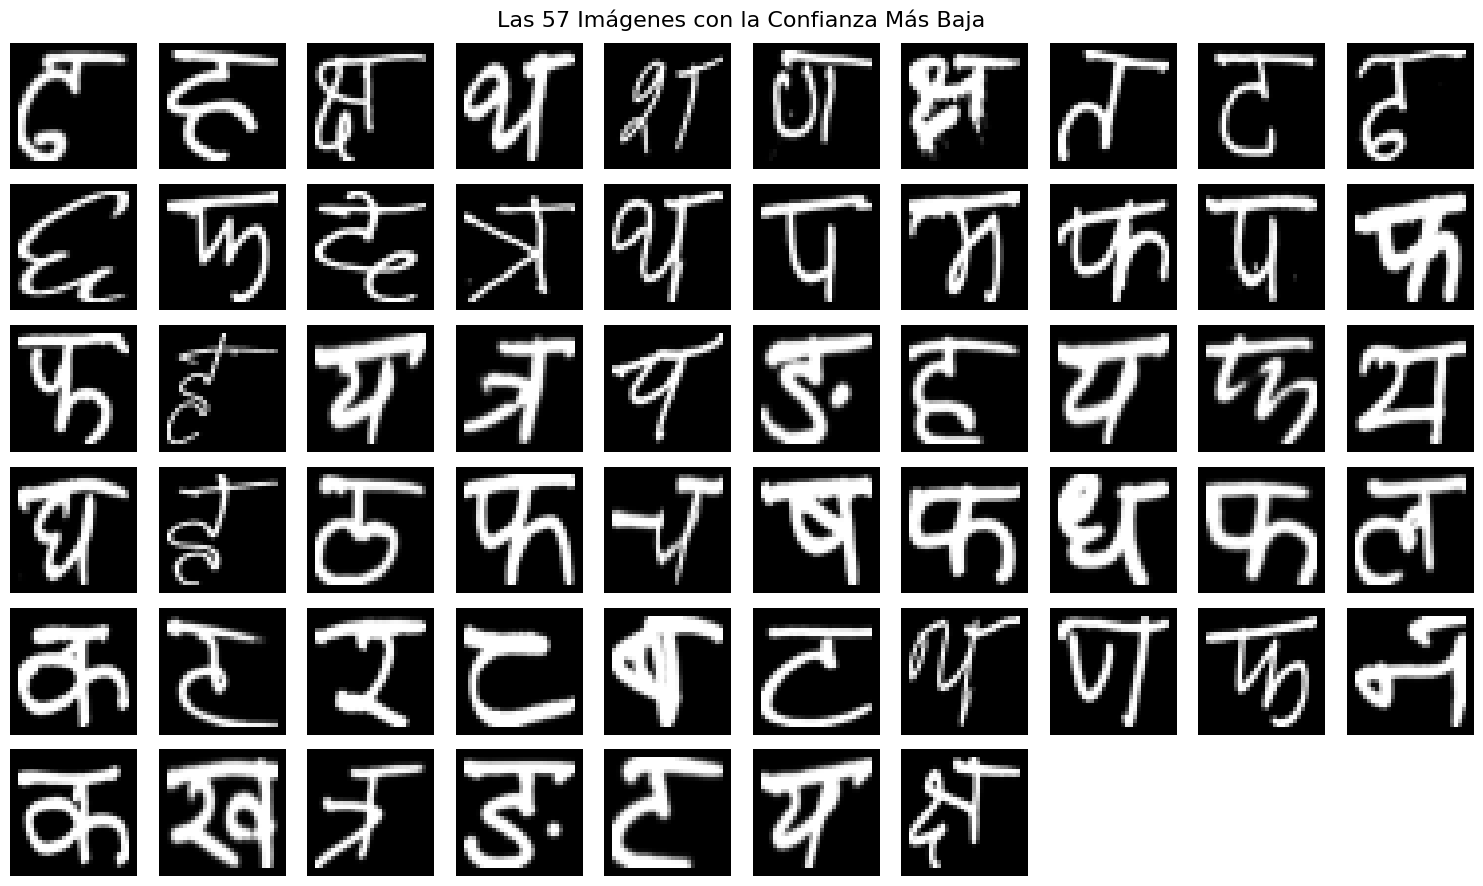

In [407]:
import matplotlib.pyplot as plt
import math

# Definimos cuántas imágenes "difíciles" vamos a revisar
#k_revisar = k
k = 57
X_lowest = X_train[:1000][sorted_ixs[:k]]

filas = math.ceil(k / 10)
plt.figure(figsize=(15, 1.5 * filas))
for index, img in enumerate(X_lowest):
    plt.subplot(filas, 10, index + 1)
    # Reconstruimos la imagen a 32x32 para visualización
    plt.imshow(img.reshape(32, 32), cmap="gray")
    plt.axis('off')

plt.suptitle(f"Las {k} Imágenes con la Confianza Más Baja", fontsize=16)
plt.tight_layout()
plt.show()

In [408]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([ 4, 25, 26,  7, 22,  5, 26,  6,  1,  4, 42, 13,  8, 27,  7, 12, 16,
       13, 12, 13, 13, 25, 17, 27, 32, 31, 25, 17, 13, 17, 30, 25,  2, 13,
       32, 23, 13,  9, 13, 19, 10,  1, 18, 44, 14,  1,  7,  5, 13, 11, 10,
       21, 27, 31,  1, 17, 26])

In [411]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [412]:
from sklearn.linear_model import LogisticRegression

log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

%time log_reg5.fit(X_train[:1000], y_train2)

score = log_reg5.score(X_test, y_test)
print(f"Precisión final tras aprendizaje activo: {score * 100:.2f}%")

CPU times: user 13.6 s, sys: 10.6 ms, total: 13.7 s
Wall time: 9.33 s
Precisión final tras aprendizaje activo: 23.66%
